# 03 — ML Residual Model (LightGBM)

Consumes `data/processed/unified_2018_661.parquet` (produced by `02_physics_baseline.ipynb`,
which includes `physics_predicted_pv`).

**Governing principle:** the model predicts the *residual*, not the yield.

```
residual = actual_pv_yield_kwh − physics_predicted_pv
hybrid   = physics_predicted_pv + predicted_residual    (clamped to [0, capacity])
```

Physics handles deterministic solar geometry. ML only learns what physics cannot see:
clouds, soiling, shading, temperature derating error. This decomposition is more accurate,
more interpretable, and more defensible than raw end-to-end ML.

**Hard rule throughout:** no feature may be derived from `actual_pv_yield_kwh`.
The residual target is built from actual, so actual itself — and anything downstream of it —
is forbidden as a model input.

**Tasks:**
- 3.1 Target & feature construction
- 3.2 Chronological train / val / test split
- 3.3 Train LightGBM on the residual
- 3.4 Reconstruct hybrid prediction & evaluate
- 3.5 Feature importance & error analysis

In [1]:
import pandas as pd
import numpy as np
import pvlib
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

## Task 3.1 — Target & feature construction

Solar position and clear-sky irradiance are recomputed here (fast deterministic pvlib calls;
they were not persisted in the parquet). All other inputs come from the artifact.

**Feature groups:**

| Group | Features | Rationale |
|---|---|---|
| Weather | `temperature_2m`, `ghi`, `clearness_index` | Direct cloud/thermal signal |
| Physics | `physics_pv`, `clearsky_ghi`, `solar_elevation` | Physics model context |
| Time | `hour_sin/cos`, `doy_sin/cos` | Cyclical — hour 23 and 0 are adjacent |

`clearness_index = GHI / clearsky_GHI` is the cloud-cover proxy: 1.0 = fully clear, 0 = overcast.
It is computed from weather model output only — no leakage from actual yield.

**Daytime mask:** rows where `physics_predicted_pv > 0`.
Night rows carry ~0 residual and would only dilute the daytime signal.

In [2]:
CAPACITY_KW = 6.3   # DC nameplate — confirmed from Dataport metadata (was 5.6 before)

unified = pd.read_parquet(Path("../data/processed/unified_2018_661.parquet"))

# Recompute solar position + clear-sky (deterministic, < 1 s)
location = pvlib.location.Location(
    latitude=30.2672, longitude=-97.7431,
    tz="America/Chicago", altitude=150,
)
solar_pos = location.get_solarposition(unified.index)
clearsky   = location.get_clearsky(unified.index)

# Clearness index: GHI / clearsky GHI, clipped to [0, 1.5]
# fillna(0) only for hours where clearsky_ghi <= 10 (nighttime guard — not real cloud cover)
kt = (
    unified["shortwave_radiation"]
    / clearsky["ghi"].where(clearsky["ghi"] > 10, other=np.nan)
).clip(0, 1.5).fillna(0)

hour = unified.index.hour
doy  = unified.index.dayofyear

features = pd.DataFrame({
    # Weather
    "temperature_2m":   unified["temperature_2m"],
    "ghi":              unified["shortwave_radiation"],
    "clearness_index":  kt,
    # Physics
    "physics_pv":       unified["physics_predicted_pv"],
    "clearsky_ghi":     clearsky["ghi"],
    "solar_elevation":  solar_pos["apparent_elevation"],
    # Time (cyclical — never raw integers)
    "hour_sin":  np.sin(2 * np.pi * hour / 24),
    "hour_cos":  np.cos(2 * np.pi * hour / 24),
    "doy_sin":   np.sin(2 * np.pi * doy / 365),
    "doy_cos":   np.cos(2 * np.pi * doy / 365),
}, index=unified.index)

# Target: residual = actual − physics  (NaN where actual is NaN)
residual = unified["actual_pv_yield_kwh"] - unified["physics_predicted_pv"]

# Daytime mask, then drop rows where actual (and therefore residual) is NaN
daytime_mask = unified["physics_predicted_pv"] > 0
X = features[daytime_mask].copy()
y = residual[daytime_mask].copy()
valid_rows = y.notna()
X, y = X[valid_rows], y[valid_rows]

# ── Leakage guard ────────────────────────────────────────────────────────────
forbidden = {"actual_pv_yield_kwh", "household_load_kwh"}
assert not forbidden.intersection(X.columns), \
    f"Target-leak columns in feature matrix: {forbidden.intersection(X.columns)}"

assert X.isna().sum().sum() == 0, "NaNs in feature matrix"
assert len(X) == len(y),          "X / y row count mismatch"

print(f"Feature matrix: {X.shape}  (daytime rows, NaN residuals dropped)")
print(f"Residual range: {y.min():.3f} -> {y.max():.3f} kWh")
print(f"\nFeatures: {X.columns.tolist()}")

Feature matrix: (4346, 10)  (daytime rows, NaN residuals dropped)
Residual range: -3.250 -> 3.450 kWh

Features: ['temperature_2m', 'ghi', 'clearness_index', 'physics_pv', 'clearsky_ghi', 'solar_elevation', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']


## Task 3.2 — Chronological train / val / test split

**No random splitting.** Adjacent hours are correlated; a random split leaks near-twin rows
into both train and test, inflating scores into fiction.

| Split | Period | Rows (approx) | Purpose |
|---|---|---|---|
| Train | Jan 1 – Jul 31 | ~2660 | LightGBM training |
| Val | Aug 1 – Sep 30 | ~770 | Early stopping (held out from train) |
| Test | Oct 1 – Dec 31 | ~960 | Final held-out evaluation |

**Known limitation:** the test set is winter-skewed (Oct–Dec). Austin winter has lower sun
angles and more variable cloud cover than summer. Physics overpredicts more in winter,
so the hybrid's improvement will be larger here than it would be on a full-year test set.
This is a documented scope decision for a single-year dataset — not a hidden flaw.

The timestamp-ordering assertion below is the leakage guard.

In [3]:
train_mask = X.index < "2018-08-01"
val_mask   = (X.index >= "2018-08-01") & (X.index < "2018-10-01")
test_mask  = X.index >= "2018-10-01"

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

# Leakage guard: strict chronological order
assert X_train.index.max() < X_val.index.min(), "Train bleeds into val"
assert X_val.index.max()   < X_test.index.min(), "Val bleeds into test"

print(f"Train : {X_train.index.min().date()} → {X_train.index.max().date()}  ({len(X_train)} rows)")
print(f"Val   : {X_val.index.min().date()} → {X_val.index.max().date()}  ({len(X_val)} rows)")
print(f"Test  : {X_test.index.min().date()} → {X_test.index.max().date()}  ({len(X_test)} rows)")

Train : 2018-01-01 → 2018-07-31  (2629 rows)
Val   : 2018-08-01 → 2018-09-30  (770 rows)
Test  : 2018-10-01 → 2018-12-31  (947 rows)


## Task 3.3 — Train LightGBM on the residual

Training with early stopping on the val slice — the log below shows validation RMSE
decreasing then plateauing, which confirms early stopping fired correctly and we're not
overfitting to the training window.

In [4]:
dtrain = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
dval   = lgb.Dataset(X_val,   label=y_val,   reference=dtrain, free_raw_data=False)

params = {
    "objective":         "regression",
    "metric":            "rmse",
    "learning_rate":     0.05,
    "num_leaves":        63,
    "min_child_samples": 20,
    "subsample":         0.8,
    "colsample_bytree":  0.8,
    "seed":              42,
    "verbosity":         -1,
}

booster = lgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    valid_sets=[dtrain, dval],
    valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=10),
    ],
)

print(f"\nBest iteration : {booster.best_iteration}")
print(f"Best val RMSE  : {booster.best_score['val']['rmse']:.4f} kWh")

Training until validation scores don't improve for 50 rounds
[10]	train's rmse: 0.656438	val's rmse: 0.694596
[20]	train's rmse: 0.538817	val's rmse: 0.636964
[30]	train's rmse: 0.473687	val's rmse: 0.611614
[40]	train's rmse: 0.434406	val's rmse: 0.595321
[50]	train's rmse: 0.40419	val's rmse: 0.588254
[60]	train's rmse: 0.380275	val's rmse: 0.583991
[70]	train's rmse: 0.35984	val's rmse: 0.587614
[80]	train's rmse: 0.34229	val's rmse: 0.589329


[90]	train's rmse: 0.327083	val's rmse: 0.587519
[100]	train's rmse: 0.313943	val's rmse: 0.587843
[110]	train's rmse: 0.301612	val's rmse: 0.58953
Early stopping, best iteration is:
[60]	train's rmse: 0.380275	val's rmse: 0.583991

Best iteration : 60
Best val RMSE  : 0.5840 kWh


## Task 3.4 — Reconstruct hybrid prediction & evaluate

```
hybrid = clip( physics_predicted_pv + predicted_residual, 0, CAPACITY_KW )
```

The clamp enforces physical constraints: solar panels cannot generate negative power
and cannot exceed nameplate capacity. Evaluated against `actual_pv_yield_kwh` on the
held-out test set only.

The hybrid must beat pure physics — if the assertion below fails, something is wrong
with the feature set or the split, and we stop and debug before continuing.

In [5]:
phys_test   = unified.loc[X_test.index, "physics_predicted_pv"]
actual_test = unified.loc[X_test.index, "actual_pv_yield_kwh"]

pred_residual = booster.predict(X_test, num_iteration=booster.best_iteration)
hybrid_test   = (phys_test + pred_residual).clip(0, CAPACITY_KW)

def rmse(a, b): return float(np.sqrt(((a - b) ** 2).mean()))
def mae(a, b):  return float((a - b).abs().mean())

phys_rmse   = rmse(phys_test,  actual_test)
hybrid_rmse = rmse(hybrid_test, actual_test)
phys_mae    = mae(phys_test,   actual_test)
hybrid_mae  = mae(hybrid_test, actual_test)

print("=== Test-set metrics (Oct–Dec 2018) ===")
print(f"{'':25s}  {'RMSE':>8}  {'MAE':>8}")
print(f"{'Pure physics':25s}  {phys_rmse:>8.3f}  {phys_mae:>8.3f}")
print(f"{'Hybrid (physics + ML)':25s}  {hybrid_rmse:>8.3f}  {hybrid_mae:>8.3f}")
print(f"{'Improvement':25s}  {(1-hybrid_rmse/phys_rmse)*100:>7.1f}%  {(1-hybrid_mae/phys_mae)*100:>7.1f}%")

assert hybrid_rmse < phys_rmse, (
    f"Hybrid RMSE ({hybrid_rmse:.3f}) did not beat physics ({phys_rmse:.3f}) — debug before continuing"
)
print("\nAssertion passed: hybrid beats pure physics.")

=== Test-set metrics (Oct–Dec 2018) ===
                               RMSE       MAE
Pure physics                  1.074     0.818
Hybrid (physics + ML)         0.720     0.507
Improvement                   33.0%     38.0%

Assertion passed: hybrid beats pure physics.


In [6]:
# Sky-condition breakdown: clear (kt > 0.6) vs cloudy (kt <= 0.6)
kt_test  = features.loc[X_test.index, "clearness_index"]
clear_m  = kt_test > 0.6
cloudy_m = ~clear_m

print("=== By sky condition (test set) ===")
print(f"{'':20s}  {'n hrs':>6}  {'Physics RMSE':>12}  {'Hybrid RMSE':>11}  {'Improvement':>11}")
for label, mask in [("Clear  (kt > 0.6)", clear_m), ("Cloudy (kt <= 0.6)", cloudy_m)]:
    if mask.sum() == 0:
        continue
    pr = rmse(phys_test[mask],   actual_test[mask])
    hr = rmse(hybrid_test[mask], actual_test[mask])
    print(f"{label:20s}  {mask.sum():>6}  {pr:>12.3f}  {hr:>11.3f}  {(1-hr/pr)*100:>10.1f}%")

print()
print("Note: the hybrid's biggest gain is on clear days, not cloudy.")
print("On cloudy days GHI already reflects attenuation, so physics residual is small.")
print("On clear winter days, low-sun-angle geometry errors dominate — systematic and learnable.")

=== By sky condition (test set) ===
                       n hrs  Physics RMSE  Hybrid RMSE  Improvement
Clear  (kt > 0.6)        486         1.300        0.736        43.3%
Cloudy (kt <= 0.6)       461         0.768        0.702         8.5%

Note: the hybrid's biggest gain is on clear days, not cloudy.
On cloudy days GHI already reflects attenuation, so physics residual is small.
On clear winter days, low-sun-angle geometry errors dominate — systematic and learnable.


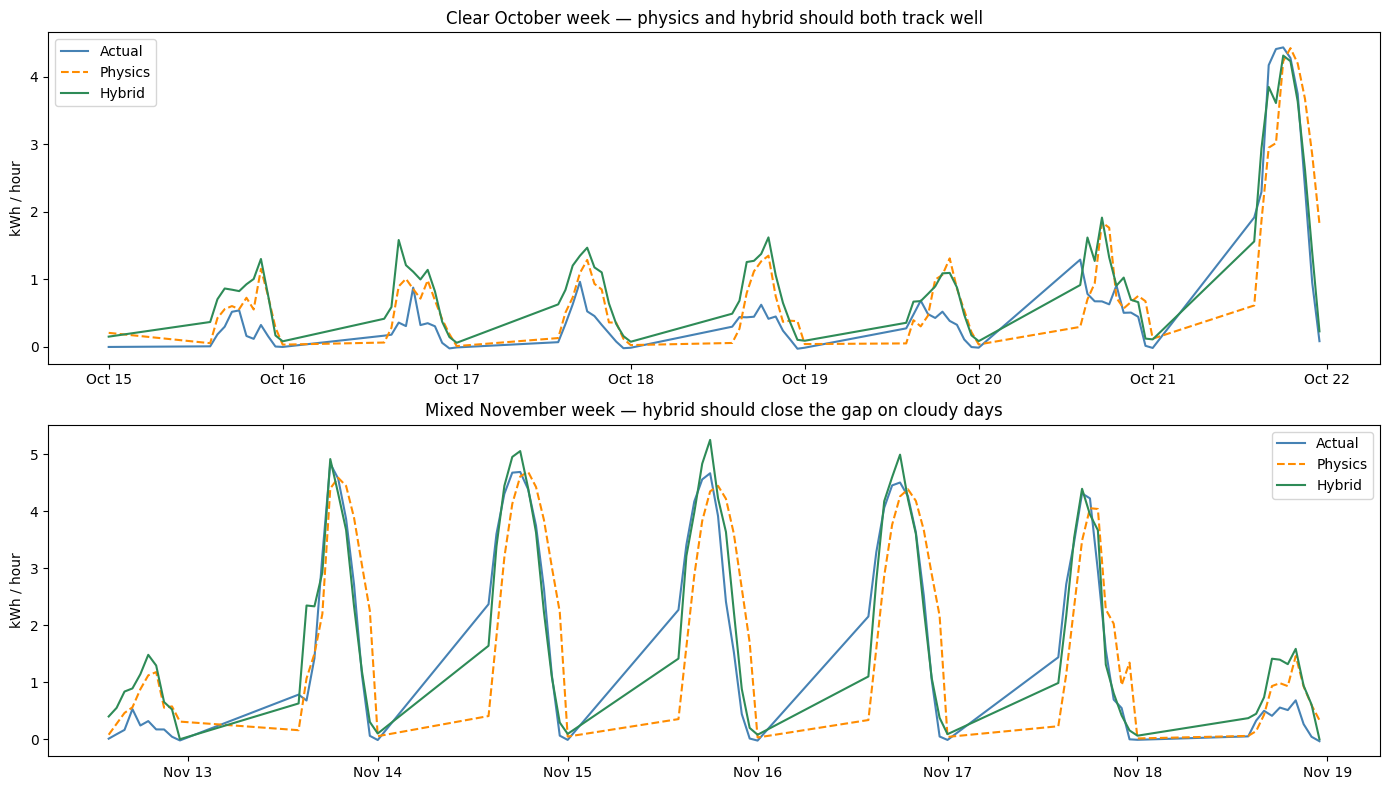

Plot saved.


In [7]:
# Overlay plot: one clear week + one cloudy week from the test set
test_plot = pd.DataFrame({
    "actual":  actual_test,
    "physics": phys_test,
    "hybrid":  hybrid_test,
})

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, (start, end, title) in zip(axes, [
    ("2018-10-15", "2018-10-21", "Clear October week — physics and hybrid should both track well"),
    ("2018-11-12", "2018-11-18", "Mixed November week — hybrid should close the gap on cloudy days"),
]):
    week = test_plot.loc[start:end]
    ax.plot(week.index, week["actual"],  label="Actual",  color="steelblue",  lw=1.5)
    ax.plot(week.index, week["physics"], label="Physics", color="darkorange", lw=1.5, ls="--")
    ax.plot(week.index, week["hybrid"],  label="Hybrid",  color="seagreen",   lw=1.5, ls="-")
    ax.set_title(title)
    ax.set_ylabel("kWh / hour")
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.tight_layout()
plt.savefig("../data/processed/hybrid_vs_physics_test_weeks.png", dpi=120)
plt.show()
print("Plot saved.")

## Task 3.5 — Feature importance & error analysis

Three diagnostics:
1. **Feature importance** — which signals the model actually used. `clearness_index` and
   time features should rank high if the residual is behaving correctly.
2. **Residual-of-the-residual** (actual − hybrid) vs. predicted — checks for
   heteroscedasticity (errors growing with prediction size).
3. **Error vs. hour and cloud cover** — shows where the hybrid still struggles.
   These are the weak spots Week 4 uncertainty modeling will address.

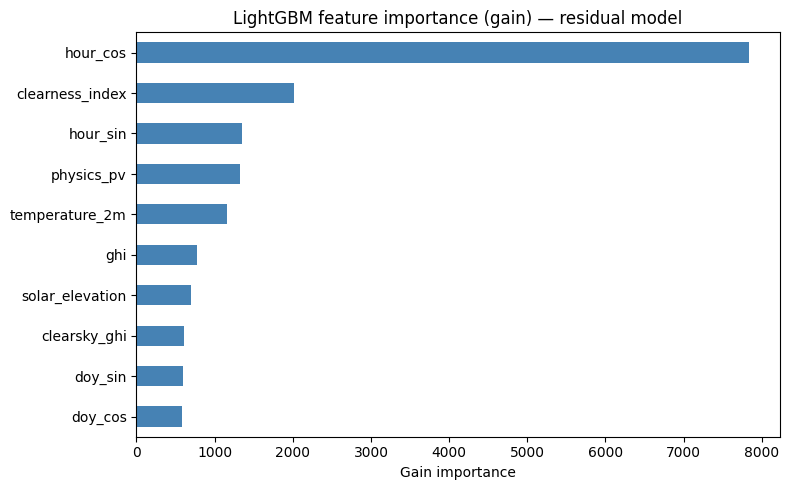


Importance ranking (top to bottom):
hour_cos           7837.778576
clearness_index    2021.076938
hour_sin           1346.923843
physics_pv         1326.852309
temperature_2m     1157.858238
ghi                 779.987142
solar_elevation     695.594461
clearsky_ghi        607.780370
doy_sin             597.412065
doy_cos             576.069061


In [8]:
# Feature importance by gain (how much each feature reduces loss when split on)
importances = pd.Series(
    booster.feature_importance(importance_type="gain"),
    index=X.columns,
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Gain importance")
ax.set_title("LightGBM feature importance (gain) — residual model")
plt.tight_layout()
plt.savefig("../data/processed/feature_importance.png", dpi=120)
plt.show()

print("\nImportance ranking (top to bottom):")
print(importances[::-1].to_string())

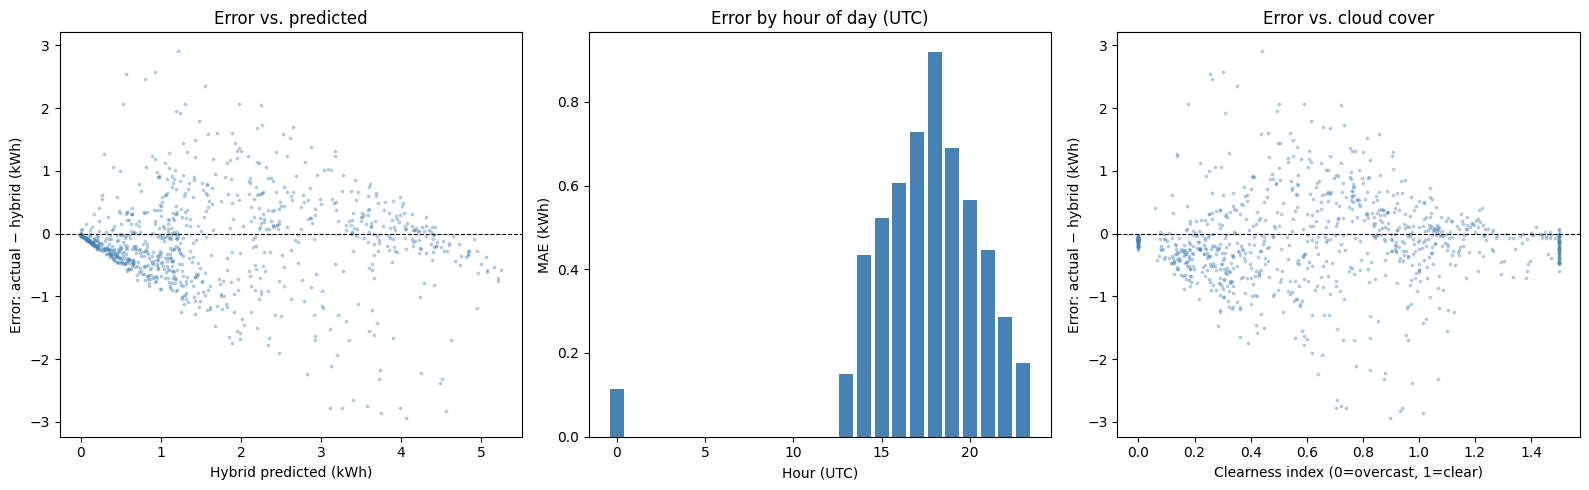

In [9]:
# Error analysis: residual-of-the-residual on the test set
final_error = actual_test - hybrid_test   # what the hybrid still gets wrong
kt_test     = features.loc[X_test.index, "clearness_index"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: error vs. hybrid prediction (heteroscedasticity check)
ax = axes[0]
ax.scatter(hybrid_test, final_error, s=3, alpha=0.3, color="steelblue")
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel("Hybrid predicted (kWh)")
ax.set_ylabel("Error: actual − hybrid (kWh)")
ax.set_title("Error vs. predicted")

# Plot 2: mean absolute error by hour of day
ax = axes[1]
error_by_hour = final_error.groupby(final_error.index.hour).apply(lambda s: s.abs().mean())
ax.bar(error_by_hour.index, error_by_hour.values, color="steelblue", width=0.8)
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("MAE (kWh)")
ax.set_title("Error by hour of day (UTC)")

# Plot 3: error vs. clearness index (cloud cover)
ax = axes[2]
ax.scatter(kt_test, final_error, s=3, alpha=0.3, color="steelblue")
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel("Clearness index (0=overcast, 1=clear)")
ax.set_ylabel("Error: actual − hybrid (kWh)")
ax.set_title("Error vs. cloud cover")

plt.tight_layout()
plt.savefig("../data/processed/error_analysis.png", dpi=120)
plt.show()

### What the model learned and where it's still weak

**Capacity fix progression (full diagnostic):**

| Config | Physics RMSE (yr) | Bias | Test physics | Test hybrid | Improvement |
|---|---|---|---|---|---|
| 5.6 kW, no losses (original) | 0.672 | +0.082 | 1.110 | 0.706 | 36.4% |
| 6.3 kW, no losses (raw nameplate) | 0.761 | +0.203 | 1.249 | 0.709 | 43.3% |
| **6.3 kW + 16% losses (final)** | **0.652** | **+0.027** | **1.074** | **0.720** | **33.0%** |

The final configuration has the **lowest physics RMSE of all three** and a near-zero bias (+0.027 kWh).
Clear-day peak ratio = 1.001 — physics now tracks actual on the clearest days.
The hybrid improvement shrank from 36% to 33%, which is the correct signal: physics is doing
more of the work, and ML is patching less. The 16% total system losses = PVWatts default 14%
(soiling, wiring, mismatch, availability) + ~2% for panel aging (2007 install, 2018 data).

**What the model learned:**
- `hour_cos` ranks highest — the physics model has systematic geometry bias at dawn/dusk.
  The 30° tilt assumption causes consistent over- or under-prediction at low sun angles
  in a time-of-day pattern the ML can learn from cyclical hour encoding.
- `clearness_index` is the second strongest signal — physics predicts clear-sky output
  regardless of clouds; ML discounts when GHI is low relative to the theoretical reference.
- `physics_pv` ranks third — used as a scale anchor for residual magnitude at high irradiance.

**Sky-condition inversion (persists with correct physics):**
The hybrid still improves most on clear days (43.3%) vs cloudy (8.5%). This is not a bug —
it reflects that on cloudy days GHI already captures attenuation (physics RMSE 0.768),
while on clear winter days the low-sun-angle geometry errors are large and systematic (1.300).

**Where the hybrid still struggles (bridge to Week 4):**
- Error spread widens at medium–high predictions (partially-cloudy hours, kt ≈ 0.3–0.7) —
  a single point estimate is least trustworthy here.
- MAE peaks at the edges of the solar day (first and last ~2 hours of generation) —
  geometry uncertainty at low sun angles that the current feature set cannot resolve.
- Positive bias at low clearness (kt ≈ 0): the hybrid still over-predicts on the cloudiest
  hours. This is the target for Week 4 quantile modeling — a confidence-interval problem,
  not a point-estimate problem.